### Objectives of this notebook
1. Load and merge the Fake and Real news datasets into a single labeled corpus.
2. Assess data quality: missing values, duplicates, and structural inconsistencies.
3. Characterize the target variable and check for class imbalance.
4. Analyze every column (`title`, `text`, `subject`, `date`) individually for its relevance to
   classification and its preprocessing implications.
5. Quantify differences between Fake and Real articles in terms of length, vocabulary, writing
   style, and metadata distribution.
6. Produce a formal Data Quality Report and a set of Key Insights that will directly inform the
   preprocessing and modeling notebook that follows.

### Questions this EDA will answer

- Is the dataset balanced between Fake and Real classes?
- Are there missing values, duplicate rows, or duplicate articles that need to be addressed?
- Do Fake and Real articles differ systematically in length (title/body)?
- Do Fake and Real articles differ in writing style (uppercase usage, punctuation, numbers)?
- Does the `subject` field leak the label (i.e., are Fake and Real subjects non-overlapping)?
- Is there a temporal pattern (does the source mix change over time) that could bias a model?
- What vocabulary (unigrams, bigrams, trigrams) is most distinctive of each class?
- What preprocessing pipeline is justified by the evidence gathered here?

---

## 1. Import Libraries

We import only the libraries required for data loading, numerical computation, visualization, and
basic NLP tokenization/stopword handling. Plot style is standardized once at the top so every
figure in the notebook shares a consistent, presentation-ready look.

In [1]:
# Core data handling
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Silence non-critical warnings for a clean, presentation-ready notebook
warnings.filterwarnings("ignore")

# One-time NLTK resource download (no-op if already present)
nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))

# Professional plotting style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "DejaVu Sans",
})

# Consistent class colors used across every plot in this notebook
CLASS_COLORS = {"Real": "#2E86AB", "Fake": "#E63946"}

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

We load the two source files.

In [2]:
from pathlib import Path
import pandas as pd

# Path to the raw data folder
DATA_DIR = Path("../data/raw")

# Load datasets
fake_df = pd.read_csv(DATA_DIR / "Fake.csv")
real_df = pd.read_csv(DATA_DIR / "Real.csv")

# Add labels
fake_df["label"] = "Fake"
real_df["label"] = "Real"

# Merge datasets
df = pd.concat([fake_df, real_df], ignore_index=True)

print("Dataset loaded successfully!")
print("Fake dataset shape:", fake_df.shape)
print("Real dataset shape:", real_df.shape)
print("Combined dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Fake dataset shape: (23481, 5)
Real dataset shape: (21417, 5)
Combined dataset shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


In [3]:
print("FAKE dataset shape:", fake_df.shape)
print("REAL dataset shape:", real_df.shape)

FAKE dataset shape: (23481, 5)
REAL dataset shape: (21417, 5)


In [4]:
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


In [5]:
real_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",Real
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",Real
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",Real
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",Real
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",Real


In [6]:
fake_df.tail()

,title,text,subject,date,label
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",Fake
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",Fake
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",Fake
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",Fake
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016",Fake


In [7]:
real_df.tail()

,title,text,subject,date,label
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017",Real
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017",Real
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017",Real
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017",Real
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017",Real


In [8]:
print("Column names (Fake):", fake_df.columns.tolist())
print("Column names (Real):", real_df.columns.tolist())
print()
print("Data types (Fake):")
print(fake_df.dtypes)
print()
print("Data types (Real):")
print(real_df.dtypes)

Column names (Fake): ['title', 'text', 'subject', 'date', 'label']
Column names (Real): ['title', 'text', 'subject', 'date', 'label']

Data types (Fake):
title      str
text       str
subject    str
date       str
label      str
dtype: object

Data types (Real):
title      str
text       str
subject    str
date       str
label      str
dtype: object


**Observations:**

- Both files share an identical schema: `title`, `text`, `subject`, `date` — all loaded as object
  (string) columns, which is expected since none of these fields are inherently numeric.
- The Fake dataset (23,481 rows) is somewhat larger than the Real dataset (21,417 rows), a ~52/48
  split that is close to balanced but not perfectly so.
- The first and last rows show article titles/text that are clearly recognizable as political news
  content, consistent with the `subject` values observed later — this dataset is domain-specific
  (predominantly US politics and world news) rather than a general-purpose news corpus, which is an
  important scope caveat for any model trained on it.
- No column is yet in a usable numeric or datetime form; `date` in particular will require careful
  parsing, since it is stored as free-text.

## 4. Merge Dataset

We label Real articles as `0` and Fake articles as `1`, concatenate both datasets into a single
DataFrame, and then **shuffle** the combined data using a fixed random seed.

In [9]:
real_df = real_df.copy()
fake_df = fake_df.copy()

real_df["target"] = 0  # Real
fake_df["target"] = 1  # Fake

real_df["label"] = "Real"
fake_df["label"] = "Fake"

df = pd.concat([real_df, fake_df], axis=0, ignore_index=True)
print("Combined shape before shuffling:", df.shape)
df.head()

Combined shape before shuffling: (44898, 6)


,title,text,subject,date,label,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",Real,0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",Real,0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",Real,0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",Real,0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",Real,0


In [10]:
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
print("Combined shape after shuffling:", df.shape)
df.head()

Combined shape after shuffling: (44898, 6)


,title,text,subject,date,label,target
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",Fake,1
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",Fake,1
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",Fake,1
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",Real,0
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",Fake,1


In [11]:
# Sanity check: shuffling preserved row count and class totals
assert df.shape[0] == real_df.shape[0] + fake_df.shape[0]
assert df["target"].value_counts().to_dict() == {
    0: real_df.shape[0], 1: fake_df.shape[0]
}
print("Merge integrity check passed: no rows lost, class counts preserved.")

Merge integrity check passed: no rows lost, class counts preserved.


**Observations:** the merged, shuffled DataFrame now has `title`, `text`, `subject`, `date`,
`target` (0/1) and a human-readable `label` (Real/Fake) column. This single DataFrame (`df`) is
used for the remainder of the notebook. The integrity check confirms the merge did not silently
drop or duplicate rows.

## 5. Initial Data Inspection

A structured first look at the merged dataset: dimensions, types, descriptive statistics, memory
footprint, and cardinality of each column.

In [12]:
print(f"Dataset dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset dimensions: 44,898 rows x 6 columns


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  str  
 5   target   44898 non-null  int64
dtypes: int64(1), str(5)
memory usage: 2.1 MB


In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,44898,38729,Factbox: Trump fills top jobs for his administ...,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,44898,38646,,627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subject,44898,8,politicsNews,11272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,44898,2397,"December 20, 2017",182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
label,44898,2,Fake,23481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,44898.0,NaN,NaN,NaN,0.522985,0.499477,0.0,0.0,1.0,1.0,1.0


In [15]:
mem_usage = df.memory_usage(deep=True)
mem_summary = (mem_usage / 1024**2).round(3).to_frame("Memory (MB)")
mem_summary.loc["TOTAL"] = mem_summary.sum()
mem_summary

,Memory (MB)
Index,0.000
title,7.165
text,135.168
subject,2.475
date,2.733
label,2.269
target,0.343
TOTAL,150.153


In [16]:
unique_counts = df.nunique().to_frame("Unique Values")
unique_counts["% Unique"] = (unique_counts["Unique Values"] / len(df) * 100).round(2)
unique_counts

,Unique Values,% Unique
title,38729,86.26
text,38646,86.08
subject,8,0.02
date,2397,5.34
label,2,0.00
target,2,0.00


### **Interpretation**

- All columns have complete entries, indicating there are no missing (`NaN`) values.
- The `subject` column contains a few categories that occur more frequently than others.
- The `text` column consumes the most memory because it stores complete news articles.
- Most `title` and `text` values are unique, while `subject` and `date` contain repeated values across multiple records.



## 6. Missing Value Analysis

We check for both **true nulls** (`NaN`) and the more subtle case of **empty or whitespace-only
strings**, which `isnull()` alone will not catch but which are functionally missing for NLP
purposes.

In [17]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(3)
missing_report = pd.DataFrame({"Missing Count": null_counts, "Missing %": null_pct})
missing_report

,Missing Count,Missing %
title,0,0.0
text,0,0.0
subject,0,0.0
date,0,0.0
label,0,0.0
target,0,0.0


In [18]:
# Whitespace/empty-string check on the two free-text columns
def blank_mask(series):
    return series.astype(str).str.strip().eq("")

blank_report = pd.DataFrame({
    "Blank Count": [blank_mask(df["title"]).sum(), blank_mask(df["text"]).sum()],
    "Blank %": [
        round(blank_mask(df["title"]).mean() * 100, 3),
        round(blank_mask(df["text"]).mean() * 100, 3),
    ],
}, index=["title", "text"])
blank_report

,Blank Count,Blank %
title,0,0.000
text,631,1.405


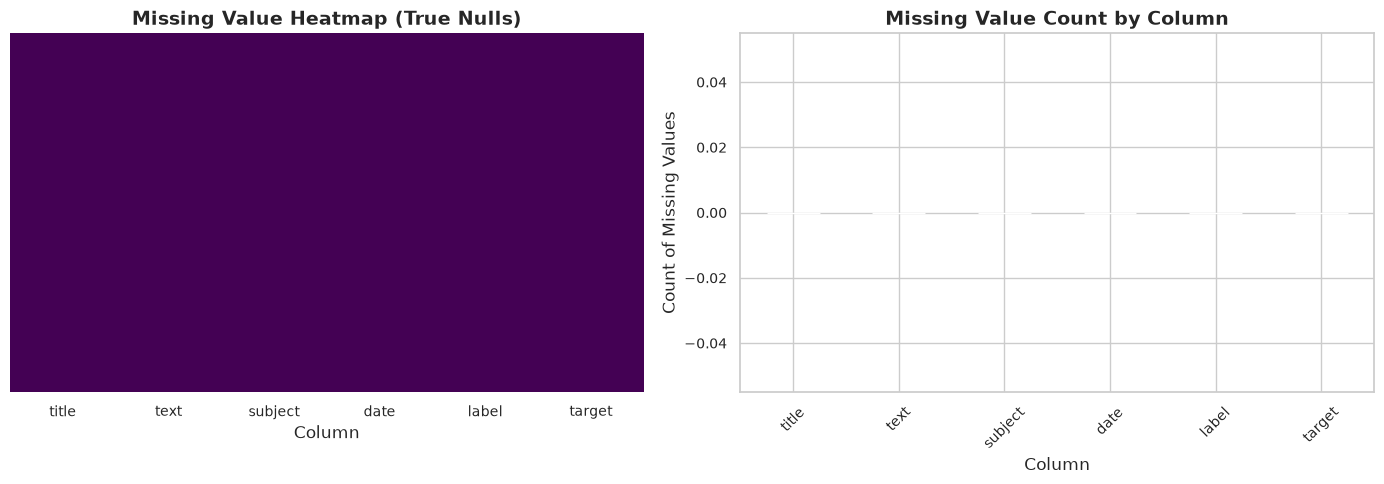

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False, ax=axes[0])
axes[0].set_title("Missing Value Heatmap (True Nulls)")
axes[0].set_xlabel("Column")

null_counts.plot(kind="bar", color="#457B9D", ax=axes[1])
axes[1].set_title("Missing Value Count by Column")
axes[1].set_xlabel("Column")
axes[1].set_ylabel("Count of Missing Values")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
blank_by_class = pd.DataFrame({
    "Real": [blank_mask(df.loc[df.target == 0, "title"]).sum(),
             blank_mask(df.loc[df.target == 0, "text"]).sum()],
    "Fake": [blank_mask(df.loc[df.target == 1, "title"]).sum(),
             blank_mask(df.loc[df.target == 1, "text"]).sum()],
}, index=["title", "text"])
blank_by_class

,Real,Fake
title,0,0
text,1,630


### **Interpretation**

- No missing (`NaN`) values are present in the dataset.
- Some rows have an empty `text` field, mostly in the **Fake** news category.
- Since the main news content is missing, these rows cannot be imputed. They should either be removed or handled using the `title` during preprocessing.
- If such rows are removed, the class distribution should be checked again.

## 7. Duplicate Analysis

In [21]:
dup_rows = df.duplicated().sum()
dup_titles = df["title"].duplicated().sum()
dup_texts = df["text"].duplicated().sum()

dup_summary = pd.DataFrame({
    "Duplicate Type": ["Full Row", "Title Only", "Text Only"],
    "Duplicate Count": [dup_rows, dup_titles, dup_texts],
    "Duplicate %": [round(dup_rows / len(df) * 100, 2),
                     round(dup_titles / len(df) * 100, 2),
                     round(dup_texts / len(df) * 100, 2)],
})
dup_summary

,Duplicate Type,Duplicate Count,Duplicate %
0,Full Row,209,0.47
1,Title Only,6169,13.74
2,Text Only,6252,13.92


In [22]:
dup_by_class = df[df["title"].duplicated(keep=False)].groupby("label").size().rename("Rows Involved in a Duplicate Title")
dup_by_class

label
Fake    10674
Real     1124
Name: Rows Involved in a Duplicate Title, dtype: int64

In [23]:
df[df["title"].duplicated(keep=False)].sort_values("title")[["title", "label"]].head(10)

,title,label
14396,McConnell Says He’ll Obstruct ANY Effort To H...,Fake
29643,McConnell Says He’ll Obstruct ANY Effort To H...,Fake
3828,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,Fake
3487,#AnyoneButHillary: NEW POLL Shows Bernie Suppo...,Fake
184,#Austin: Fights Break Out Between Police and S...,Fake
21075,#Austin: Fights Break Out Between Police and S...,Fake
7239,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Fake
31596,#Berkeley CRAZY! RIOTERS CHASE And Beat People...,Fake
39783,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Fake
36967,#Berkeley IRONY ALERT! ANARCHISTS LOOT STARBUC...,Fake


### **Interpretation**

- Very few complete duplicate articles are present, but duplicate titles are more common, especially in the **Fake** news category.
- Duplicate articles can lead to biased model performance if similar news appears in both the training and testing datasets.
- These duplicates should be removed before splitting the data to ensure a fair evaluation of the model.

## 8. Target Variable Analysis

We quantify the class balance between Fake (`target=1`) and Real (`target=0`) articles, since class
imbalance directly affects the choice of evaluation metric and resampling strategy in modeling.

In [24]:
class_counts = df["label"].value_counts()
class_pct = (df["label"].value_counts(normalize=True) * 100).round(2)
class_summary = pd.DataFrame({"Count": class_counts, "Percentage": class_pct})
class_summary

,Count,Percentage
label,,
Fake,23481,52.3
Real,21417,47.7


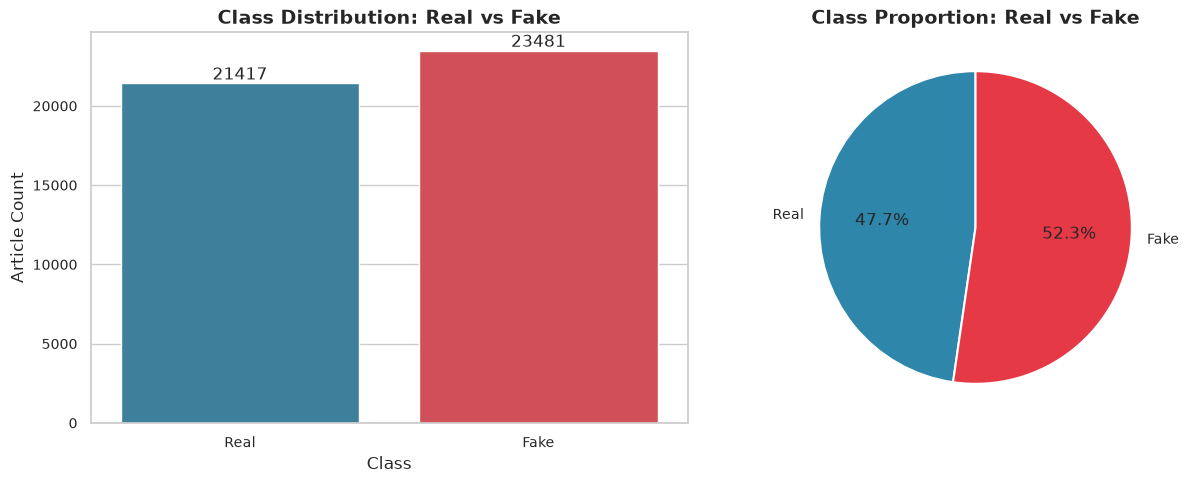

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="label", hue="label", order=["Real", "Fake"],
              palette=CLASS_COLORS, legend=False, ax=axes[0])
axes[0].set_title("Class Distribution: Real vs Fake")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Article Count")
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(
    class_counts.reindex(["Real", "Fake"]),
    labels=["Real", "Fake"],
    autopct="%1.1f%%",
    colors=[CLASS_COLORS["Real"], CLASS_COLORS["Fake"]],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Class Proportion: Real vs Fake")

plt.tight_layout()
plt.show()

### **Interpretation**

- The dataset is nearly balanced, with slightly more **Fake** news articles than **Real** ones.
- This small imbalance is not significant enough to require resampling techniques.
- A stratified train-validation-test split should be sufficient, and metrics like Precision, Recall, and F1-score should be reported along with Accuracy.

## 10. Text Length Analysis

We engineer four length-based features and compare their distributions across Fake and Real
articles. Length is one of the cheapest and often most predictive signals in fake news detection.

In [26]:
df["title_character_length"] = df["title"].astype(str).str.len()
df["title_word_count"] = df["title"].astype(str).str.split().str.len()
df["text_character_length"] = df["text"].astype(str).str.len()
df["text_word_count"] = df["text"].astype(str).str.split().str.len()

df[["title_character_length", "title_word_count",
    "text_character_length", "text_word_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
title_character_length,44898.0,80.111720,25.379685,8.0,63.0,73.0,91.0,286.0
title_word_count,44898.0,12.453472,4.111476,1.0,10.0,11.0,14.0,42.0
text_character_length,44898.0,2469.109693,2171.617091,1.0,1234.0,2186.0,3105.0,51794.0
text_word_count,44898.0,405.282284,351.265595,0.0,203.0,362.0,513.0,8135.0


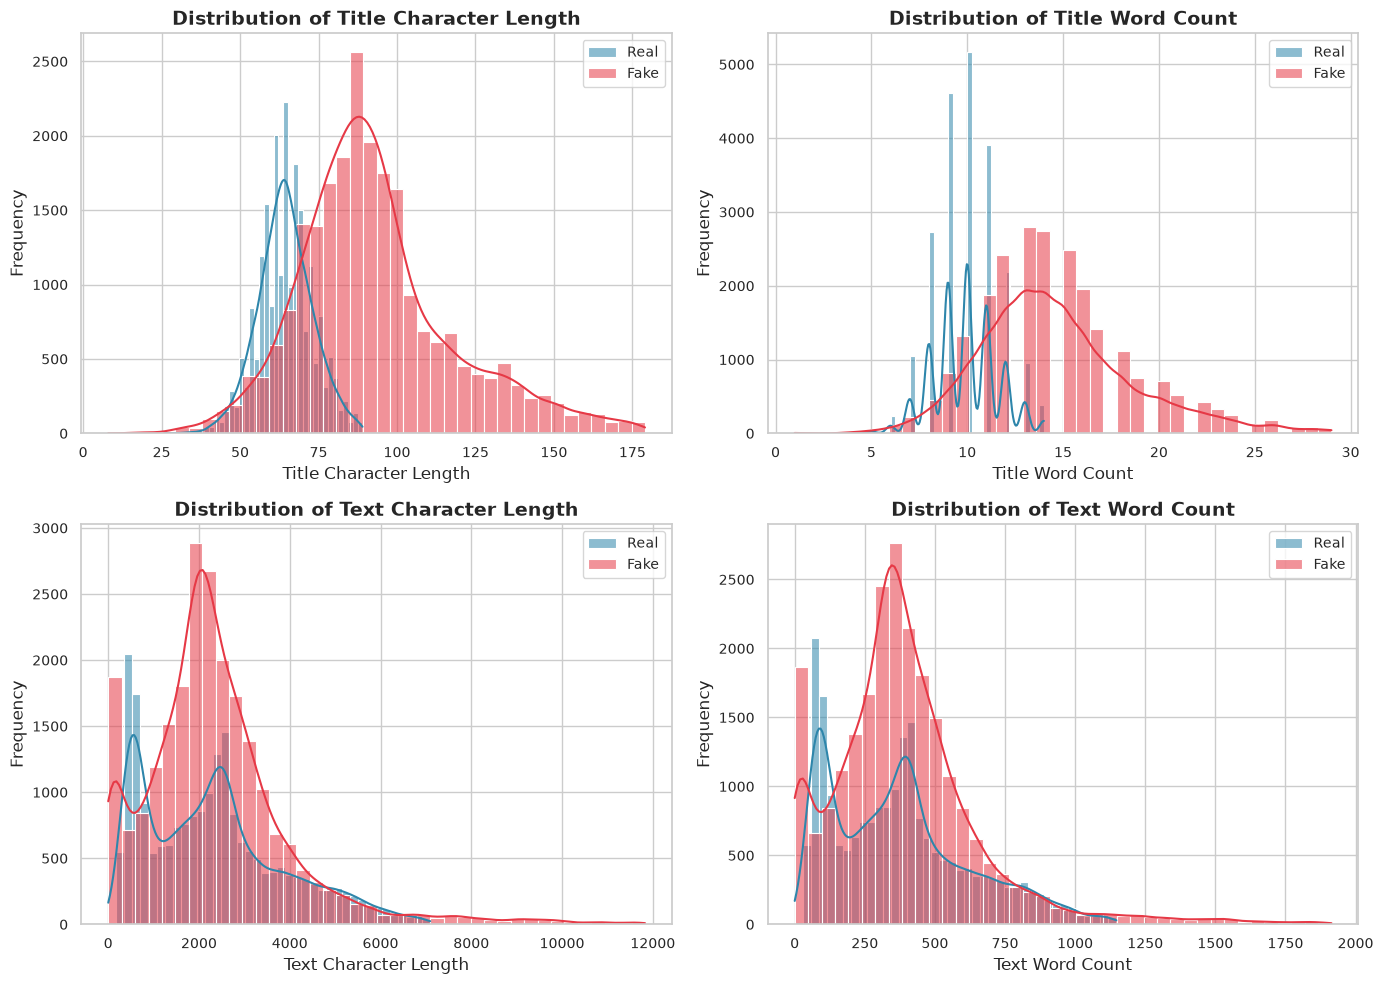

In [27]:
length_features = ["title_character_length", "title_word_count",
                    "text_character_length", "text_word_count"]
titles_map = {
    "title_character_length": "Title Character Length",
    "title_word_count": "Title Word Count",
    "text_character_length": "Text Character Length",
    "text_word_count": "Text Word Count",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for i, feat in enumerate(length_features):
    for lbl in ["Real", "Fake"]:
        subset = df.loc[df["label"] == lbl, feat]
        # Clip extreme upper tail purely for histogram readability (does not affect stats above)
        clip_val = subset.quantile(0.99)
        sns.histplot(subset[subset <= clip_val], bins=40, color=CLASS_COLORS[lbl],
                     label=lbl, alpha=0.55, ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {titles_map[feat]}")
    axes[i].set_xlabel(titles_map[feat])
    axes[i].set_ylabel("Frequency")
    axes[i].legend()
plt.tight_layout()
plt.show()

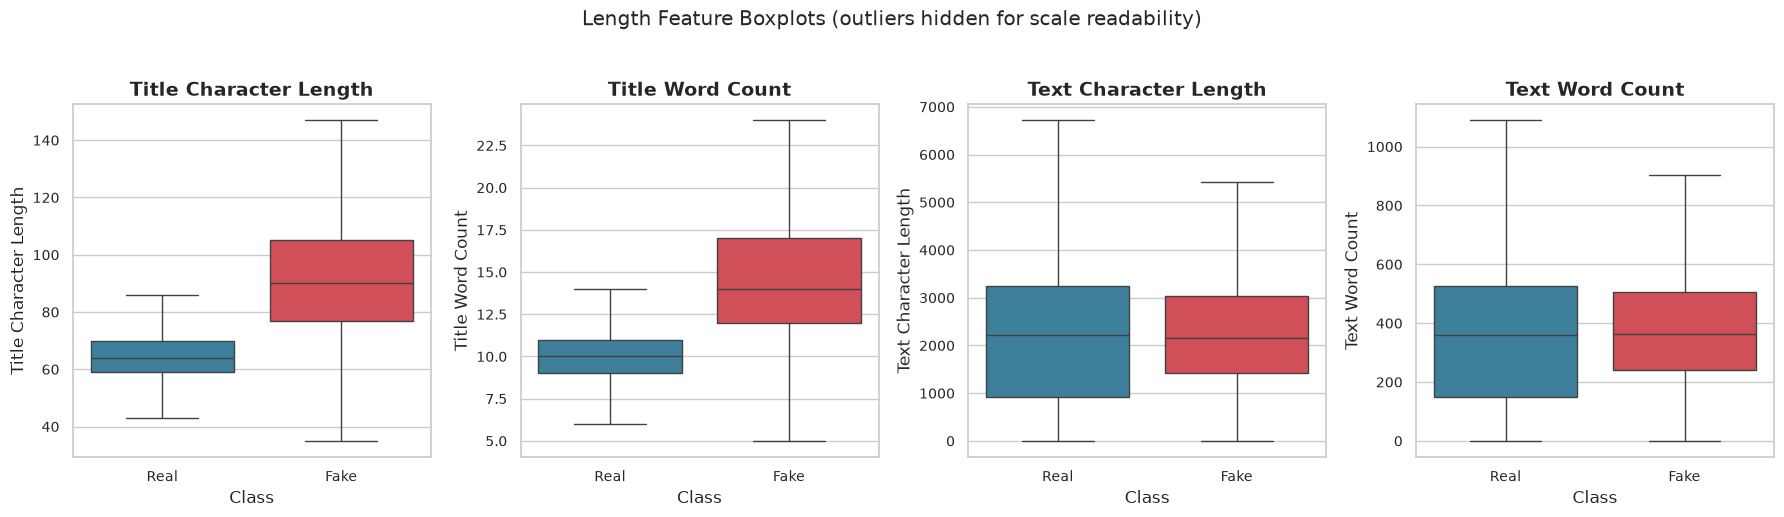

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, feat in enumerate(length_features):
    sns.boxplot(data=df, x="label", y=feat, hue="label", order=["Real", "Fake"],
                palette=CLASS_COLORS, legend=False, ax=axes[i], showfliers=False)
    axes[i].set_title(titles_map[feat])
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(titles_map[feat])
plt.suptitle("Length Feature Boxplots (outliers hidden for scale readability)", y=1.03)
plt.tight_layout()
plt.show()

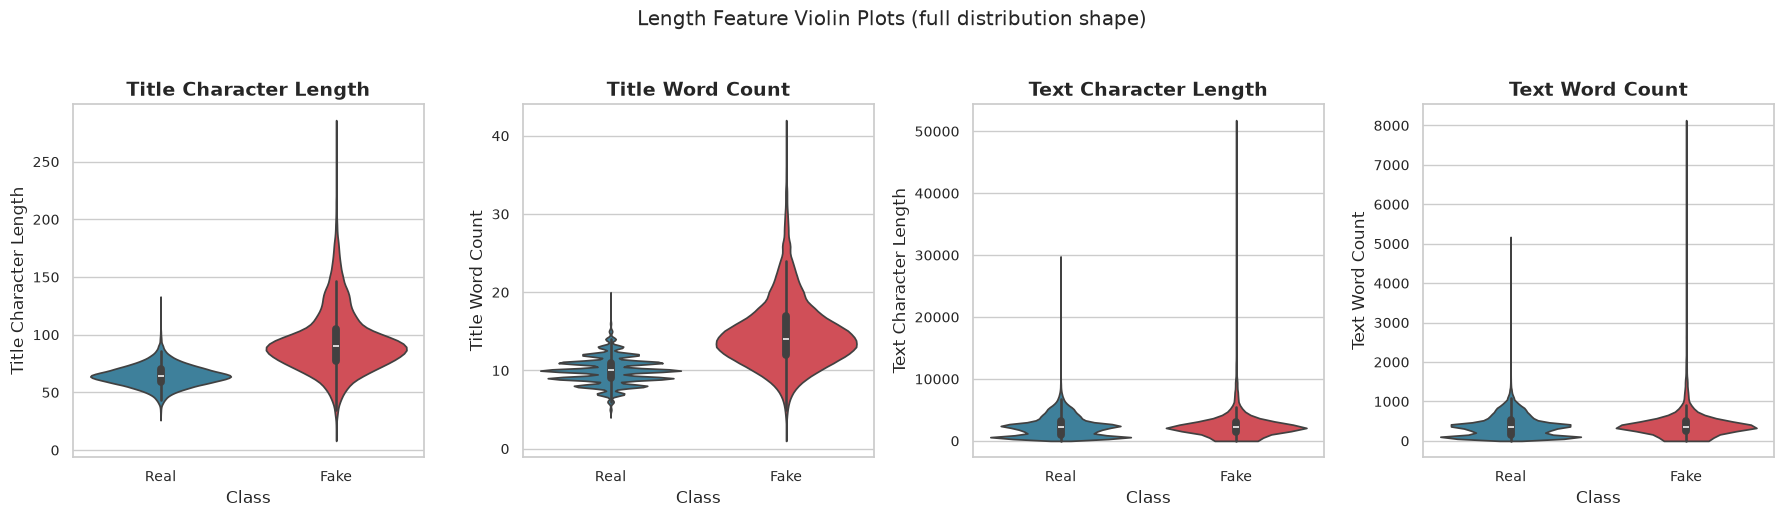

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, feat in enumerate(length_features):
    sns.violinplot(data=df, x="label", y=feat, hue="label", order=["Real", "Fake"],
                    palette=CLASS_COLORS, legend=False, ax=axes[i], cut=0)
    axes[i].set_title(titles_map[feat])
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(titles_map[feat])
plt.suptitle("Length Feature Violin Plots (full distribution shape)", y=1.03)
plt.tight_layout()
plt.show()

In [30]:
length_by_class = df.groupby("label")[length_features].median().round(1)
length_by_class.loc["Fake - Real (median diff)"] = (
    length_by_class.loc["Fake"] - length_by_class.loc["Real"]
)
length_by_class

,title_character_length,title_word_count,text_character_length,text_word_count
label,,,,
Fake,90.0,14.0,2166.0,363.0
Real,64.0,10.0,2222.0,359.0
Fake - Real (median diff),26.0,4.0,-56.0,4.0


### **Interpretation**

- Fake news titles are generally **longer** than real news titles, suggesting they may use more attention-grabbing language.
- The body text length is similar for both classes, but fake news articles show greater variation in length.
- These observations indicate that **title length** and **text length** could be useful features for the classification model.

## 11. Subject Analysis



In [31]:
subject_counts = df["subject"].value_counts()
subject_pct = (df["subject"].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({"Count": subject_counts, "Percentage": subject_pct})

,Count,Percentage
subject,,
politicsNews,11272,25.11
worldnews,10145,22.60
News,9050,20.16
politics,6841,15.24
left-news,4459,9.93
Government News,1570,3.50
US_News,783,1.74
Middle-east,778,1.73


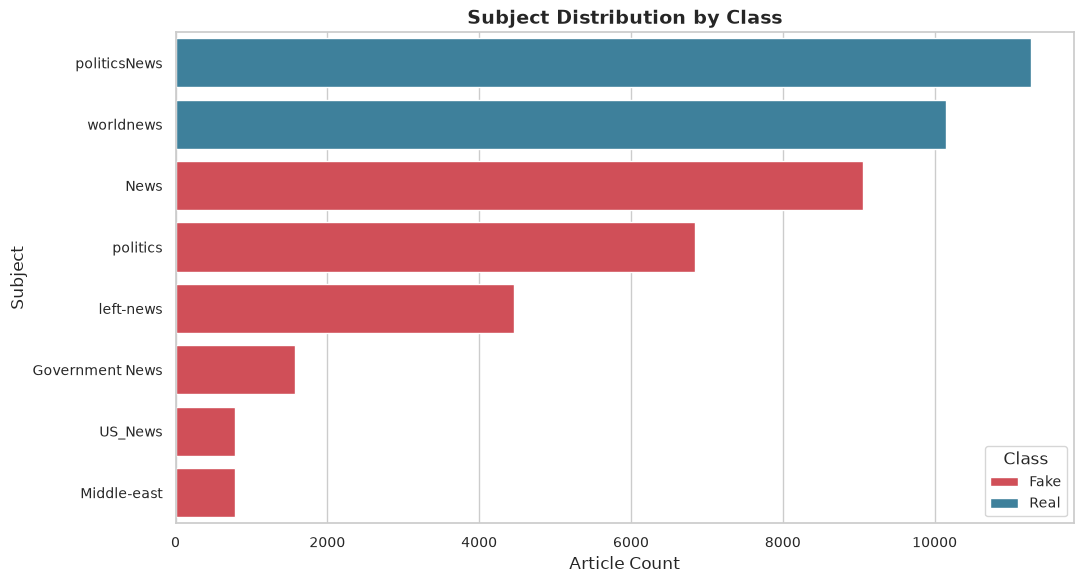

In [32]:
fig, ax = plt.subplots(figsize=(11, 6))
order = subject_counts.index
sns.countplot(data=df, y="subject", order=order, hue="label",
              palette=CLASS_COLORS, ax=ax)
ax.set_title("Subject Distribution by Class")
ax.set_xlabel("Article Count")
ax.set_ylabel("Subject")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

In [33]:
subject_class_crosstab = pd.crosstab(df["subject"], df["label"])
subject_class_pct = (subject_class_crosstab.div(subject_class_crosstab.sum(axis=1), axis=0) * 100).round(1)
subject_class_pct

label,Fake,Real
subject,,
Government News,100.0,0.0
Middle-east,100.0,0.0
News,100.0,0.0
US_News,100.0,0.0
left-news,100.0,0.0
politics,100.0,0.0
politicsNews,0.0,100.0
worldnews,0.0,100.0


In [34]:
real_subjects = set(df.loc[df["label"] == "Real", "subject"].unique())
fake_subjects = set(df.loc[df["label"] == "Fake", "subject"].unique())
overlap = real_subjects & fake_subjects

print("Subjects appearing in Real articles:", sorted(real_subjects))
print("Subjects appearing in Fake articles:", sorted(fake_subjects))
print("Subjects appearing in BOTH classes:", sorted(overlap) if overlap else "NONE")

Subjects appearing in Real articles: ['politicsNews', 'worldnews']
Subjects appearing in Fake articles: ['Government News', 'Middle-east', 'News', 'US_News', 'left-news', 'politics']
Subjects appearing in BOTH classes: NONE


### **Interpretation**

- The `subject` categories are almost completely separated between **Fake** and **Real** news.
- This indicates that `subject` is closely related to the target label and may cause **data leakage** if used for training.
- Therefore, `subject` will be excluded from the final model and used only for exploratory analysis.

## 12. Date Analysis

The `date` column is free-text and, as we will see, not perfectly clean. We parse it into a proper
`datetime` type, explicitly track parsing failures rather than silently discarding them, and analyze
publication frequency over time.

In [35]:
df["date_clean"] = df["date"].astype(str).str.strip()
df["date_parsed"] = pd.to_datetime(df["date_clean"], format="mixed", errors="coerce")

n_failed = df["date_parsed"].isna().sum()
print(f"Rows where date parsing failed: {n_failed} ({n_failed / len(df) * 100:.3f}% of dataset)")
df.loc[df["date_parsed"].isna(), ["label", "date"]].head(10)

Rows where date parsing failed: 10 (0.022% of dataset)


,label,date
13550,Fake,https://100percentfedup.com/12-yr-old-black-co...
16730,Fake,https://fedup.wpengine.com/wp-content/uploads/...
18327,Fake,https://fedup.wpengine.com/wp-content/uploads/...
18825,Fake,https://100percentfedup.com/video-hillary-aske...
20827,Fake,MSNBC HOST Rudely Assumes Steel Worker Would N...
22439,Fake,https://fedup.wpengine.com/wp-content/uploads/...
26511,Fake,https://100percentfedup.com/served-roy-moore-v...
32368,Fake,https://fedup.wpengine.com/wp-content/uploads/...
43173,Fake,https://fedup.wpengine.com/wp-content/uploads/...
44358,Fake,https://fedup.wpengine.com/wp-content/uploads/...


A small number of rows have a corrupted `date` field — inspecting them shows the value is not a
date at all, but a stray URL or a leaked snippet of article text. This is a genuine upstream data
entry/scraping error (almost certainly a CSV field misalignment for those specific rows) rather than
a parsing bug on our side; these rows are flagged (`NaT`) rather than dropped, so they remain
visible for the preprocessing stage to handle explicitly.

In [36]:
df["year"] = df["date_parsed"].dt.year
df["month"] = df["date_parsed"].dt.month

valid_dates = df.dropna(subset=["date_parsed"])
print(f"Date range: {valid_dates['date_parsed'].min().date()} to {valid_dates['date_parsed'].max().date()}")

Date range: 2015-03-31 to 2018-02-19


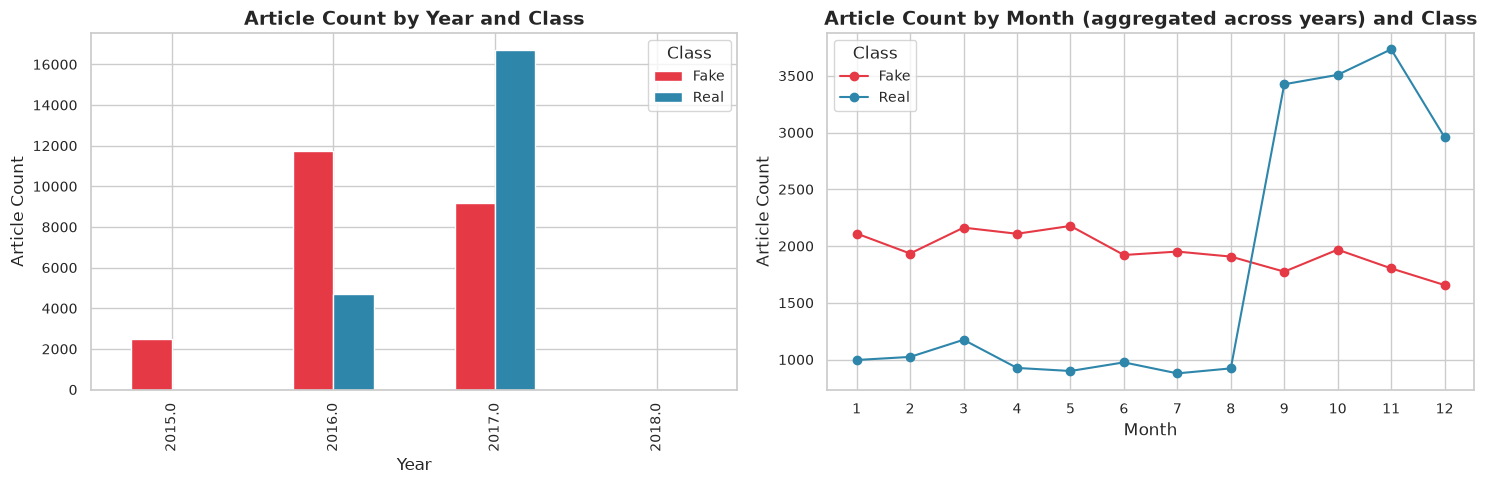

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

year_class = valid_dates.groupby(["year", "label"]).size().unstack(fill_value=0)
year_class.plot(kind="bar", color=[CLASS_COLORS["Fake"], CLASS_COLORS["Real"]], ax=axes[0])
axes[0].set_title("Article Count by Year and Class")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Article Count")
axes[0].legend(title="Class")

month_class = valid_dates.groupby(["month", "label"]).size().unstack(fill_value=0)
month_class.plot(kind="line", marker="o", color=[CLASS_COLORS["Fake"], CLASS_COLORS["Real"]], ax=axes[1])
axes[1].set_title("Article Count by Month (aggregated across years) and Class")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Article Count")
axes[1].set_xticks(range(1, 13))
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

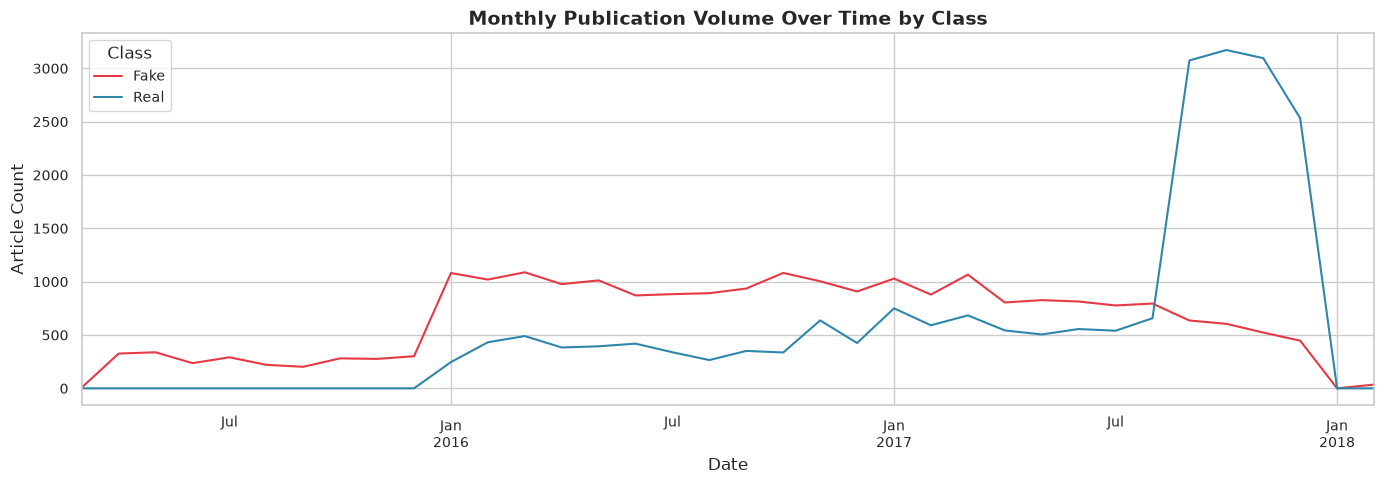

In [38]:
monthly_trend = valid_dates.set_index("date_parsed").groupby("label").resample("ME").size().unstack(0).fillna(0)
monthly_trend.plot(figsize=(14, 5), color=[CLASS_COLORS["Fake"], CLASS_COLORS["Real"]])
plt.title("Monthly Publication Volume Over Time by Class")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

### **Interpretation**

- The articles span mainly from **2015 to 2017**, with both Fake and Real news appearing during similar time periods.
- Since the date distributions overlap, the `date` column is unlikely to cause major data leakage, but it is not a strong feature for classification.
- Any invalid or missing dates should be handled during preprocessing before creating date-based features.

## 13. Text Quality Analysis

In [39]:
def avg_sentence_length(text):
    sentences = re.split(r"[.!?]+", str(text))
    sentences = [s for s in sentences if s.strip()]
    if not sentences:
        return 0.0
    word_counts = [len(s.split()) for s in sentences]
    return float(np.mean(word_counts))

def uppercase_ratio(text):
    text = str(text)
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    upper = sum(1 for c in letters if c.isupper())
    return upper / len(letters)

def punctuation_freq(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    punct_count = sum(1 for c in text if c in string.punctuation)
    return punct_count / len(text)

def numeric_freq(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    digit_count = sum(1 for c in text if c.isdigit())
    return digit_count / len(text)

# Apply to the article body (`text`), which carries most of the writing-style signal
df["avg_sentence_length"] = df["text"].apply(avg_sentence_length)
df["uppercase_ratio"] = df["text"].apply(uppercase_ratio)
df["punctuation_freq"] = df["text"].apply(punctuation_freq)
df["numeric_freq"] = df["text"].apply(numeric_freq)

quality_features = ["avg_sentence_length", "uppercase_ratio", "punctuation_freq", "numeric_freq"]
df[quality_features].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_sentence_length,44898.0,19.015238,6.176465,0.0,15.500000,18.733333,22.271853,96.250000
uppercase_ratio,44898.0,0.054756,0.044533,0.0,0.037935,0.046725,0.060020,1.000000
punctuation_freq,44898.0,0.022926,0.011850,0.0,0.018349,0.021266,0.024927,0.272873
numeric_freq,44898.0,0.006488,0.008897,0.0,0.001300,0.004286,0.008557,0.352941


In [40]:
quality_by_class = df.groupby("label")[quality_features].mean().round(4)
quality_by_class

,avg_sentence_length,uppercase_ratio,punctuation_freq,numeric_freq
label,,,,
Fake,18.1851,0.0573,0.0237,0.0072
Real,19.9253,0.0520,0.0221,0.0058


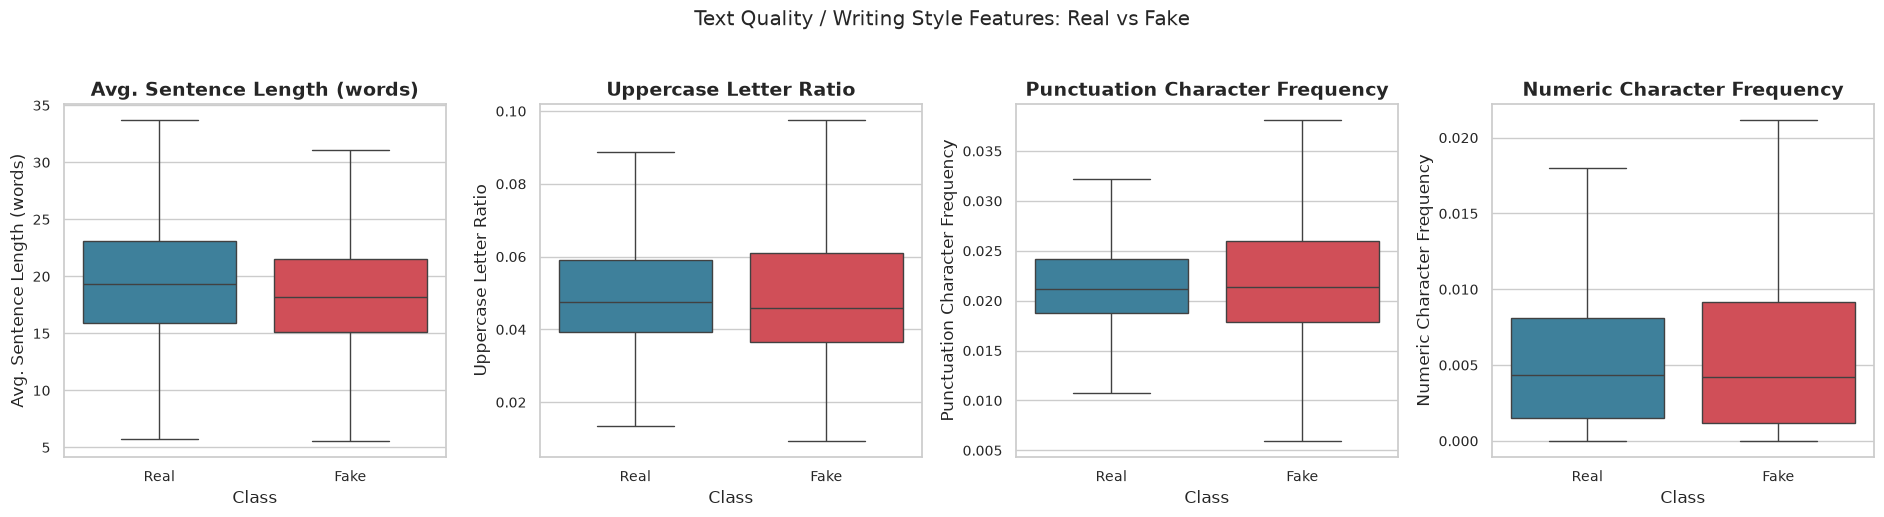

In [41]:
titles_map_q = {
    "avg_sentence_length": "Avg. Sentence Length (words)",
    "uppercase_ratio": "Uppercase Letter Ratio",
    "punctuation_freq": "Punctuation Character Frequency",
    "numeric_freq": "Numeric Character Frequency",
}
fig, axes = plt.subplots(1, 4, figsize=(19, 5))
for i, feat in enumerate(quality_features):
    sns.boxplot(data=df, x="label", y=feat, hue="label", order=["Real", "Fake"],
                palette=CLASS_COLORS, legend=False, ax=axes[i], showfliers=False)
    axes[i].set_title(titles_map_q[feat])
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(titles_map_q[feat])
plt.suptitle("Text Quality / Writing Style Features: Real vs Fake", y=1.03)
plt.tight_layout()
plt.show()

### **Interpretation**

- Fake news articles generally use more **uppercase words** and **punctuation**, making them appear more attention-grabbing.
- Sentence length and numeric content show only small differences between the two classes.
- These writing-style features may help improve the model when combined with text-based features like TF-IDF.

## 14. Word Frequency Analysis

In [42]:
TOKEN_PATTERN = re.compile(r"[^a-z\s]")

def tokenize(text):
    text = str(text).lower()
    text = TOKEN_PATTERN.sub(" ", text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

def top_n_words(series, n=30):
    counter = Counter()
    for text in series:
        counter.update(tokenize(text))
    return counter.most_common(n)

fake_top_words = top_n_words(df.loc[df["label"] == "Fake", "text"], n=30)
real_top_words = top_n_words(df.loc[df["label"] == "Real", "text"], n=30)

fake_top_df = pd.DataFrame(fake_top_words, columns=["word", "count"])
real_top_df = pd.DataFrame(real_top_words, columns=["word", "count"])
print("Top 10 Fake words:", fake_top_words[:10])
print("Top 10 Real words:", real_top_words[:10])

Top 10 Fake words: [('trump', 79939), ('said', 33763), ('president', 27811), ('people', 26591), ('one', 24593), ('would', 23566), ('clinton', 19213), ('obama', 18838), ('like', 18117), ('donald', 17790)]
Top 10 Real words: [('said', 99062), ('trump', 54702), ('would', 31605), ('reuters', 28976), ('president', 28179), ('state', 21025), ('government', 18846), ('new', 16917), ('states', 16653), ('house', 16640)]


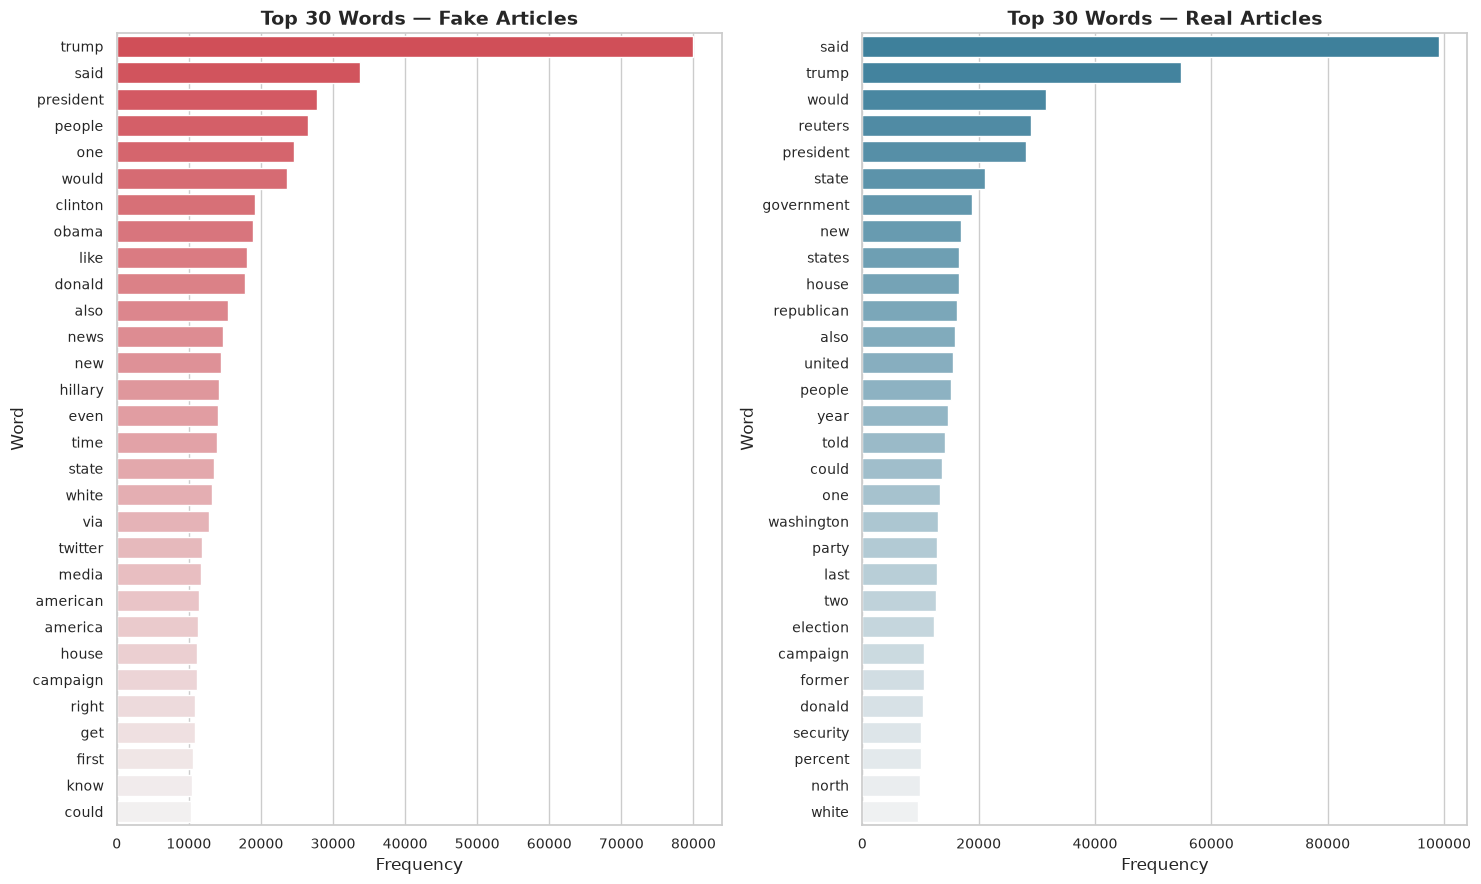

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

sns.barplot(data=fake_top_df, x="count", y="word", hue="word", legend=False,
            palette=sns.light_palette(CLASS_COLORS["Fake"], n_colors=30, reverse=True), ax=axes[0])
axes[0].set_title("Top 30 Words — Fake Articles")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

sns.barplot(data=real_top_df, x="count", y="word", hue="word", legend=False,
            palette=sns.light_palette(CLASS_COLORS["Real"], n_colors=30, reverse=True), ax=axes[1])
axes[1].set_title("Top 30 Words — Real Articles")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Word")

plt.tight_layout()
plt.show()

In [44]:
fake_word_set = set(fake_top_df["word"])
real_word_set = set(real_top_df["word"])
print("Words in Fake top-30 only:", sorted(fake_word_set - real_word_set))
print("Words in Real top-30 only:", sorted(real_word_set - fake_word_set))
print("Shared words in both top-30 lists:", sorted(fake_word_set & real_word_set))

Words in Fake top-30 only: ['america', 'american', 'clinton', 'even', 'first', 'get', 'hillary', 'know', 'like', 'media', 'news', 'obama', 'right', 'time', 'twitter', 'via']
Words in Real top-30 only: ['election', 'former', 'government', 'last', 'north', 'party', 'percent', 'republican', 'reuters', 'security', 'states', 'told', 'two', 'united', 'washington', 'year']
Shared words in both top-30 lists: ['also', 'campaign', 'could', 'donald', 'house', 'new', 'one', 'people', 'president', 'said', 'state', 'trump', 'white', 'would']


### **Interpretation**

- Both Fake and Real news share many common political terms, as they cover similar topics.
- Fake news tends to use more opinion-based or emotional words, while Real news uses more formal and institutional language.
- This suggests that individual keywords alone are not enough for classification, making techniques like **TF-IDF** more suitable for capturing meaningful patterns.

## 15. Word Clouds

In [45]:
def build_wordcloud(series, colormap):
    tokens = []
    for t in series:
        tokens.extend(tokenize(t))
    joined = " ".join(tokens)
    wc = WordCloud(
        width=1000, height=600, background_color="white",
        colormap=colormap, max_words=150, random_state=RANDOM_SEED,
    ).generate(joined)
    return wc

fake_wc = build_wordcloud(df.loc[df["label"] == "Fake", "text"], colormap="Reds")
real_wc = build_wordcloud(df.loc[df["label"] == "Real", "text"], colormap="Blues")

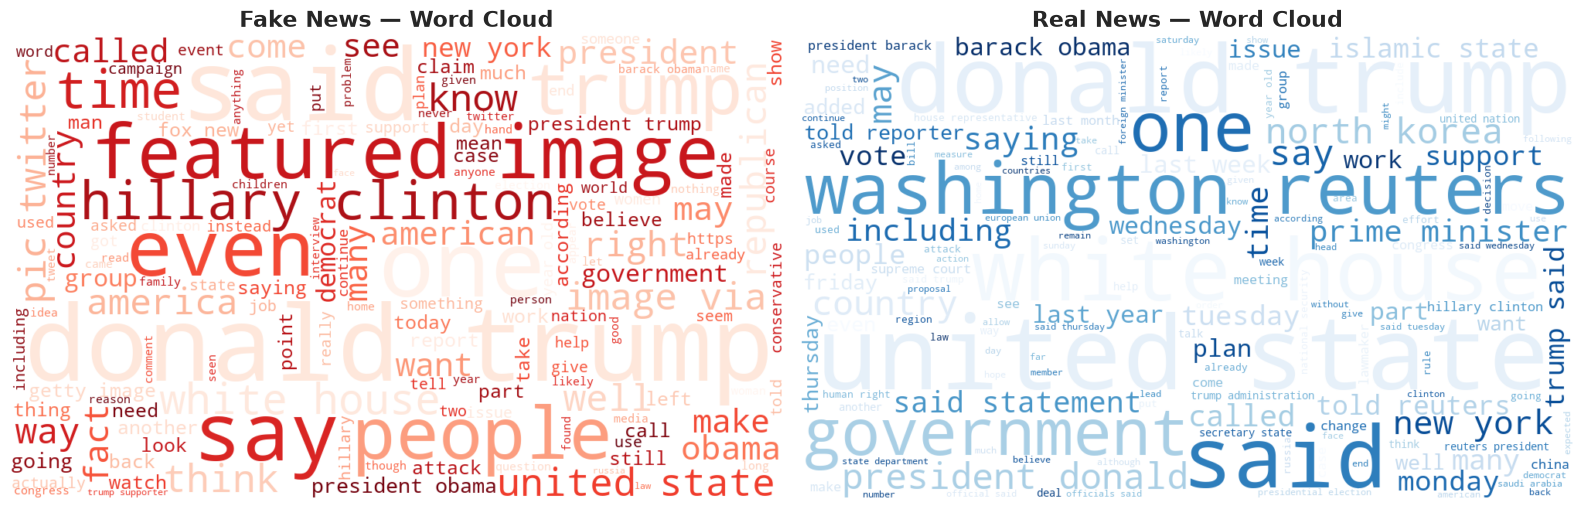

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(fake_wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Fake News — Word Cloud", fontsize=16, fontweight="bold")

axes[1].imshow(real_wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Real News — Word Cloud", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## 16. N-gram Analysis

In [47]:
def top_ngrams(series, n_gram_range, top_k=15):
    vectorizer = CountVectorizer(
        ngram_range=n_gram_range, stop_words="english", min_df=5,
    )
    matrix = vectorizer.fit_transform(series.astype(str))
    freqs = np.asarray(matrix.sum(axis=0)).ravel()
    vocab = vectorizer.get_feature_names_out()
    ranked = sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:top_k]
    return pd.DataFrame(ranked, columns=["ngram", "count"])

fake_text = df.loc[df["label"] == "Fake", "text"]
real_text = df.loc[df["label"] == "Real", "text"]

fake_unigrams = top_ngrams(fake_text, (1, 1))
real_unigrams = top_ngrams(real_text, (1, 1))
fake_bigrams = top_ngrams(fake_text, (2, 2))
real_bigrams = top_ngrams(real_text, (2, 2))
fake_trigrams = top_ngrams(fake_text, (3, 3))
real_trigrams = top_ngrams(real_text, (3, 3))

print("Top Fake bigrams:", fake_bigrams["ngram"].tolist()[:5])
print("Top Real bigrams:", real_bigrams["ngram"].tolist()[:5])

Top Fake bigrams: ['donald trump', 'featured image', 'hillary clinton', 'white house', 'united states']
Top Real bigrams: ['united states', 'donald trump', 'white house', 'washington reuters', 'president donald']


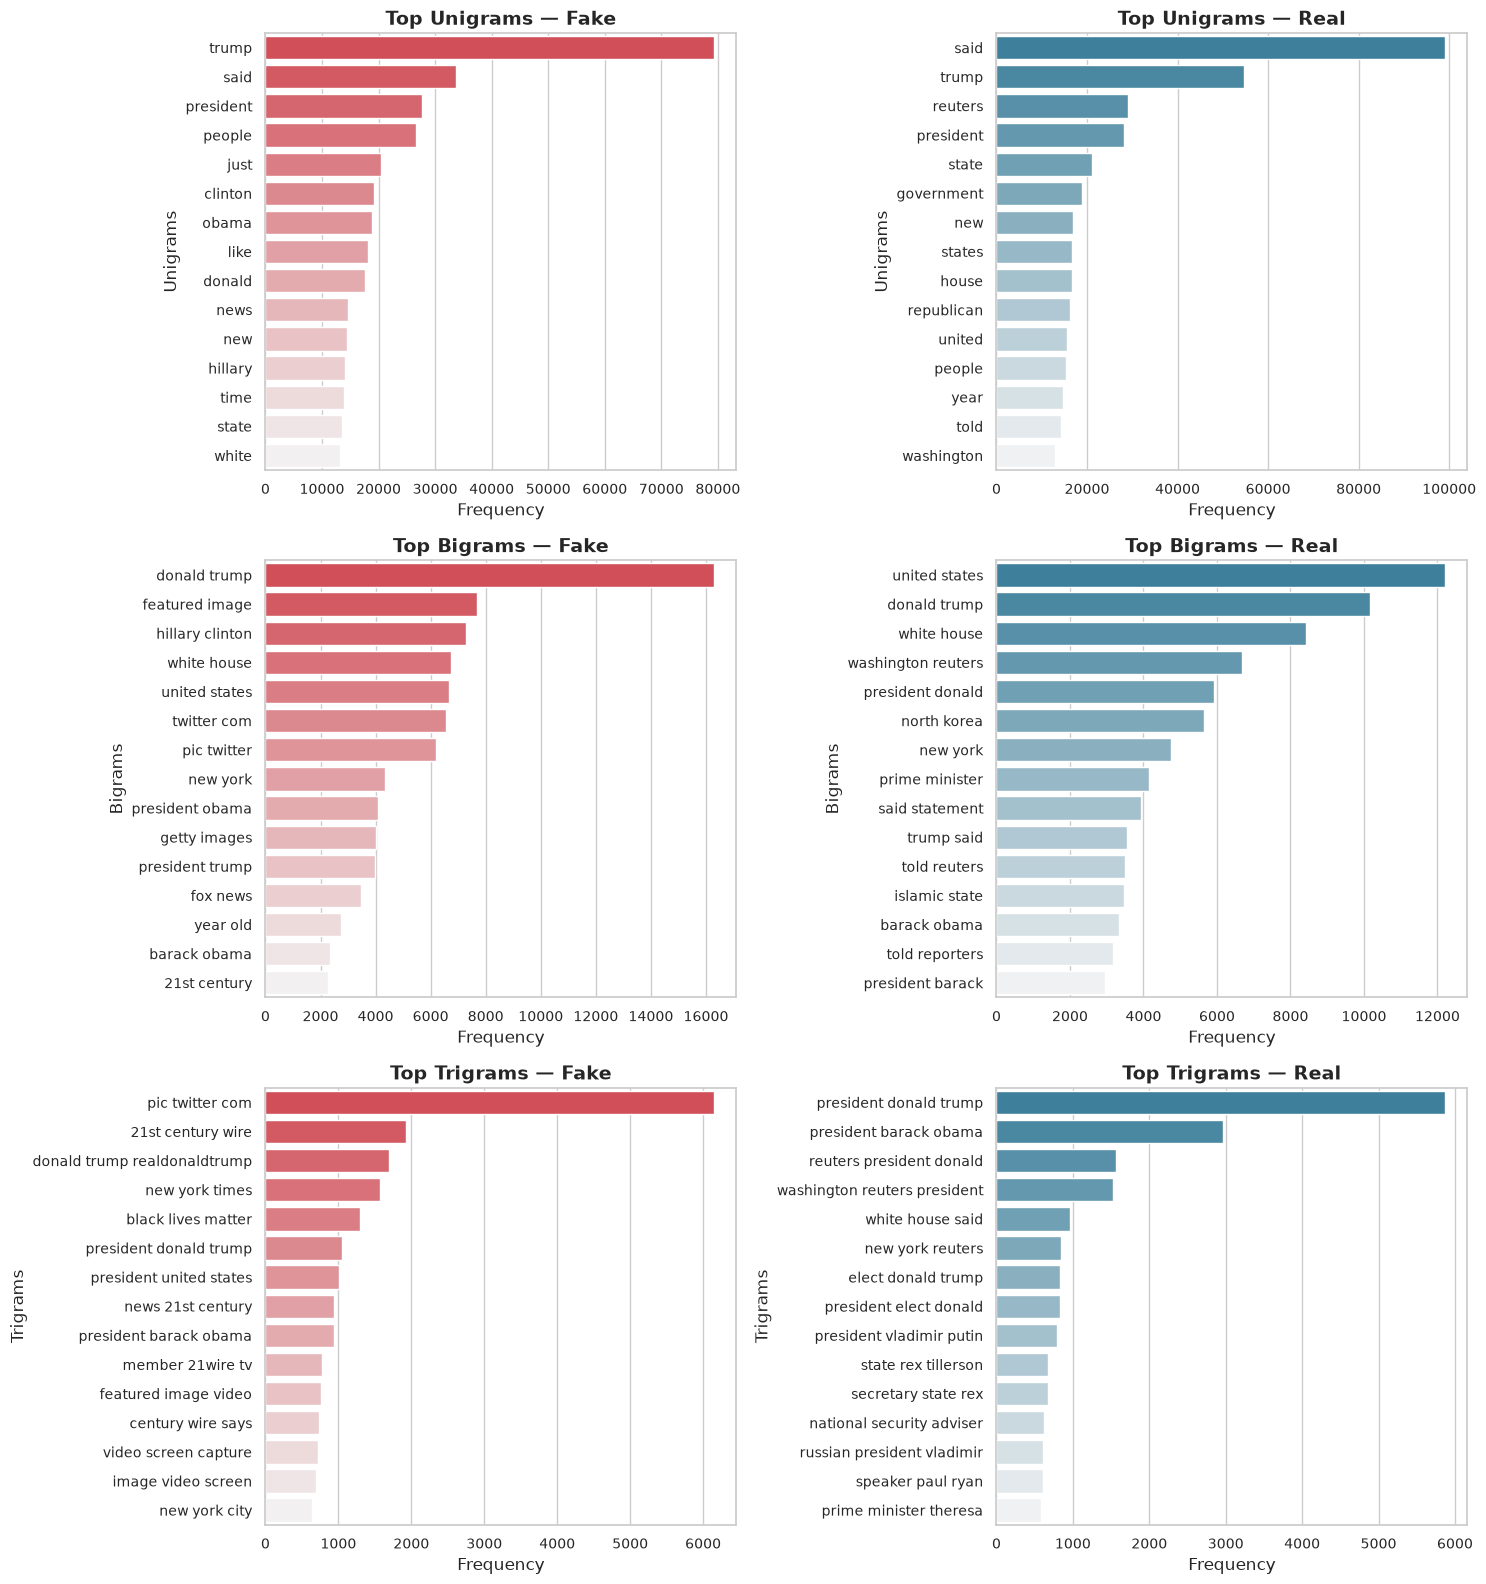

In [48]:
fig, axes = plt.subplots(3, 2, figsize=(15, 16))

pairs = [
    (fake_unigrams, real_unigrams, "Unigrams"),
    (fake_bigrams, real_bigrams, "Bigrams"),
    (fake_trigrams, real_trigrams, "Trigrams"),
]
for row, (fake_df_n, real_df_n, label_n) in enumerate(pairs):
    sns.barplot(data=fake_df_n, x="count", y="ngram", hue="ngram", legend=False,
                palette=sns.light_palette(CLASS_COLORS["Fake"], n_colors=15, reverse=True),
                ax=axes[row, 0])
    axes[row, 0].set_title(f"Top {label_n} — Fake")
    axes[row, 0].set_xlabel("Frequency")
    axes[row, 0].set_ylabel(label_n)

    sns.barplot(data=real_df_n, x="count", y="ngram", hue="ngram", legend=False,
                palette=sns.light_palette(CLASS_COLORS["Real"], n_colors=15, reverse=True),
                ax=axes[row, 1])
    axes[row, 1].set_title(f"Top {label_n} — Real")
    axes[row, 1].set_xlabel("Frequency")
    axes[row, 1].set_ylabel(label_n)

plt.tight_layout()
plt.show()

### **Interpretation**

- Bigrams and trigrams reveal more meaningful phrases than individual words, helping distinguish Fake and Real news.
- These phrase-level patterns suggest that using **TF-IDF with n-grams (1–3)** can capture more useful information than unigrams alone.

## 17. Correlation Analysis

We restrict this correlation analysis strictly to the numeric features engineered during this
notebook (length and text-quality features); raw text columns cannot be correlated directly.

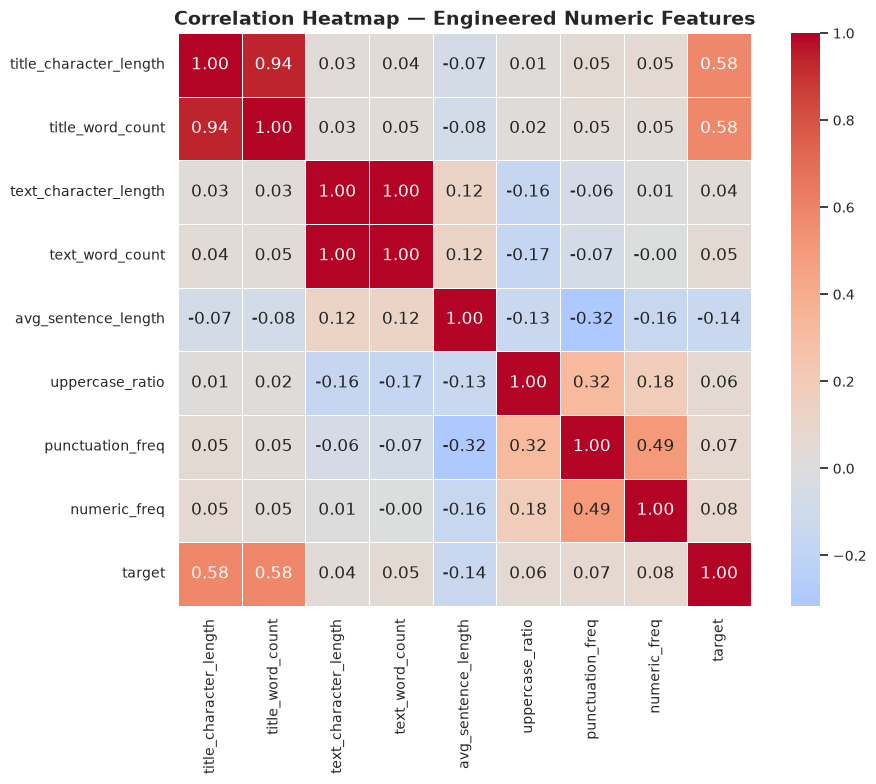

In [49]:
numeric_features = length_features + quality_features + ["target"]
corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Engineered Numeric Features")
plt.tight_layout()
plt.show()

### **Interpretation**

- Features like **uppercase ratio**, **punctuation frequency**, and **title length** show a positive relationship with Fake news.
- Some length-based features are highly correlated with each other, so one of them can be removed to avoid redundancy.
- No single feature is sufficient for classification, so combining these features with **TF-IDF text features** is expected to give better performance.

## 18. Outlier Detection

In [50]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_report = []
for feat in ["text_character_length", "text_word_count"]:
    lower, upper = iqr_outlier_bounds(df[feat])
    n_outliers = ((df[feat] < lower) | (df[feat] > upper)).sum()
    outlier_report.append({
        "feature": feat, "lower_bound": round(lower, 1), "upper_bound": round(upper, 1),
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })
pd.DataFrame(outlier_report)

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,text_character_length,-1572.5,5911.5,1767,3.94
1,text_word_count,-262.0,978.0,1678,3.74


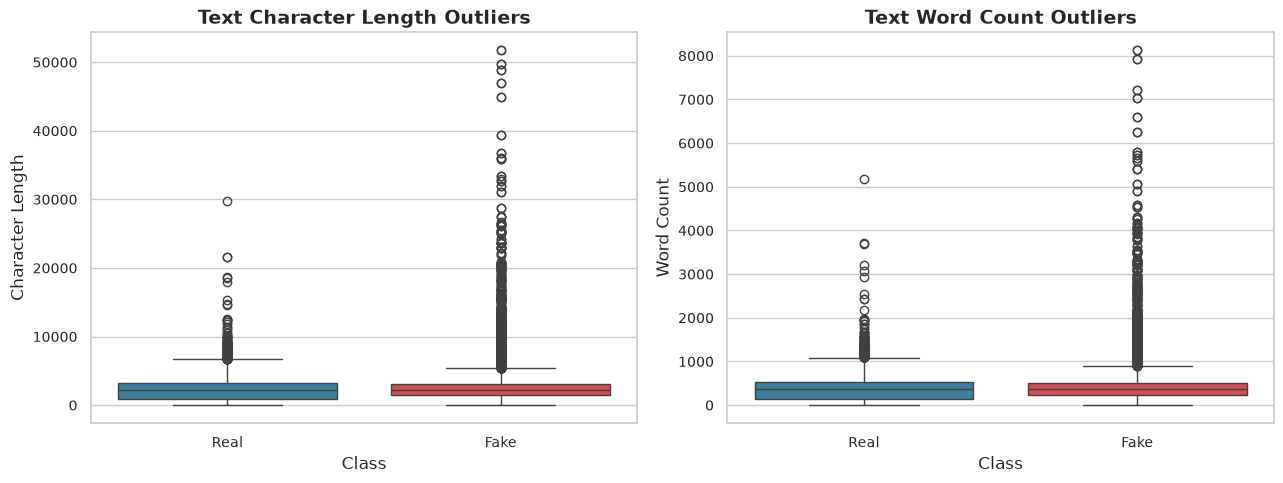

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="label", y="text_character_length", hue="label", order=["Real", "Fake"],
            palette=CLASS_COLORS, legend=False, ax=axes[0])
axes[0].set_title("Text Character Length Outliers")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Character Length")

sns.boxplot(data=df, x="label", y="text_word_count", hue="label", order=["Real", "Fake"],
            palette=CLASS_COLORS, legend=False, ax=axes[1])
axes[1].set_title("Text Word Count Outliers")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.show()

### **Interpretation**

- The dataset contains a few very short and very long articles, which are expected in real-world news data.
- These outliers should not be removed blindly, as they may contain useful information.
- Empty or near-empty articles should be handled during preprocessing, while very long articles can be truncated during tokenization.

## 19. Data Quality Report

A consolidated summary of every data-quality finding from this notebook

In [52]:
quality_report = {
    "Total rows (merged)": len(df),
    "True nulls (original raw columns)": int(df[["title", "text", "subject", "date"]].isnull().sum().sum()),
    "Blank/empty text rows": int(blank_mask(df["text"]).sum()),
    "Blank/empty title rows": int(blank_mask(df["title"]).sum()),
    "Full-row duplicates": int(dup_rows),
    "Duplicate titles": int(dup_titles),
    "Duplicate text bodies": int(dup_texts),
    "Class balance (Real / Fake)": f"{class_pct['Real']}% / {class_pct['Fake']}%",
    "Unparseable dates": int(n_failed),
    "Subject/label overlap": "None (subject fully leaks label)" if not overlap else f"Partial overlap: {sorted(overlap)}",
    "Text length outliers (char, IQR)": int(outlier_report[0]['n_outliers']),
    "Text length outliers (words, IQR)": int(outlier_report[1]['n_outliers']),
}
quality_report_df = pd.DataFrame(list(quality_report.items()), columns=["Check", "Result"])
quality_report_df

,Check,Result
0,Total rows (merged),44898
1,True nulls (original raw columns),0
2,Blank/empty text rows,631
3,Blank/empty title rows,0
4,Full-row duplicates,209
5,Duplicate titles,6169
6,Duplicate text bodies,6252
7,Class balance (Real / Fake),47.7% / 52.3%
8,Unparseable dates,10
9,Subject/label overlap,None (subject fully leaks label)
